# Exploración reproducible del dataset Brain Tumor MRI Scans

Este notebook presenta la contribución individual de exploración de datos para la Entrega 1. La lógica se mantiene en `scripts/run_eda.py`; aquí se ejecuta y se muestran sus resultados sin entrenar modelos ni realizar interpretaciones médicas.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image as DisplayImage, Markdown, display

candidates = [Path.cwd(), *Path.cwd().parents]
repo_root = next(path for path in candidates if (path / 'scripts' / 'run_eda.py').exists())
sys.path.insert(0, str(repo_root))

from scripts.run_eda import run_analysis

data_dir = repo_root / 'data' / 'brain-tumor-mri-scans'
output_dir = repo_root / 'reports'
seed = 42
print(f'Repositorio: {repo_root.name}')

Repositorio: maia-pds-microproyecto


## Ejecución del análisis

La ejecución inspecciona los archivos reales, verifica su lectura, calcula hashes SHA-256 y regenera todos los resultados.

In [2]:
results = run_analysis(data_dir=data_dir, output_dir=output_dir, seed=seed)
results['summary']

{'total_image_files': 7023,
 'readable_images': 7023,
 'duplicate_groups': 300,
 'cross_class_duplicate_groups': 0,
 'partitions': ['sin_particion']}

## Inventario y calidad

In [3]:
display(results['inventory'])
display(results['quality'])

,particion,clase,numero_imagenes,porcentaje_dataset
0,sin_particion,glioma,1621,23.0813
1,sin_particion,meningioma,1645,23.4230
2,sin_particion,pituitary,1757,25.0178
3,sin_particion,healthy,2000,28.4779


,metrica,valor,detalle
0,archivos_totales,7023,Todos los archivos encontrados
1,archivos_de_imagen,7023,Archivos con extensión esperada o reconocidos ...
2,imagenes_legibles,7023,Imágenes verificadas y decodificadas por Pillow
3,archivos_vacios,0,Tamaño igual a 0 bytes
4,imagenes_no_legibles,0,Archivos candidatos que Pillow no pudo verific...
5,extensiones_no_esperadas,0,"Extensiones distintas de .jpg, .jpeg y .png"
6,clases_esperadas_vacias,0,Ninguna
7,clases_no_esperadas,0,Ninguna
8,dimensiones_atipicas,1574,"Área en log2 fuera de 1,5 IQR; si IQR=0, área ..."
9,grupos_duplicados_exactos,300,Grupos con el mismo SHA-256


## Propiedades de las imágenes

,metrica,minimo,p05,p25,mediana,p75,p95,maximo
0,ancho_px,150.0000,206.0000,393.0000,512.0000,512.0000,512.0000,1920.0000
1,alto_px,168.0000,221.0000,403.5000,512.0000,512.0000,512.0000,1446.0000
2,relacion_aspecto,0.6448,0.8156,1.0000,1.0000,1.0000,1.0328,1.7857
3,tamano_kib,7.2715,13.1565,25.7139,36.7607,45.5796,55.5225,332.8311
4,intensidad_gris_global,0.0000,0.0000,3.0000,30.0000,74.0000,137.0000,255.0000


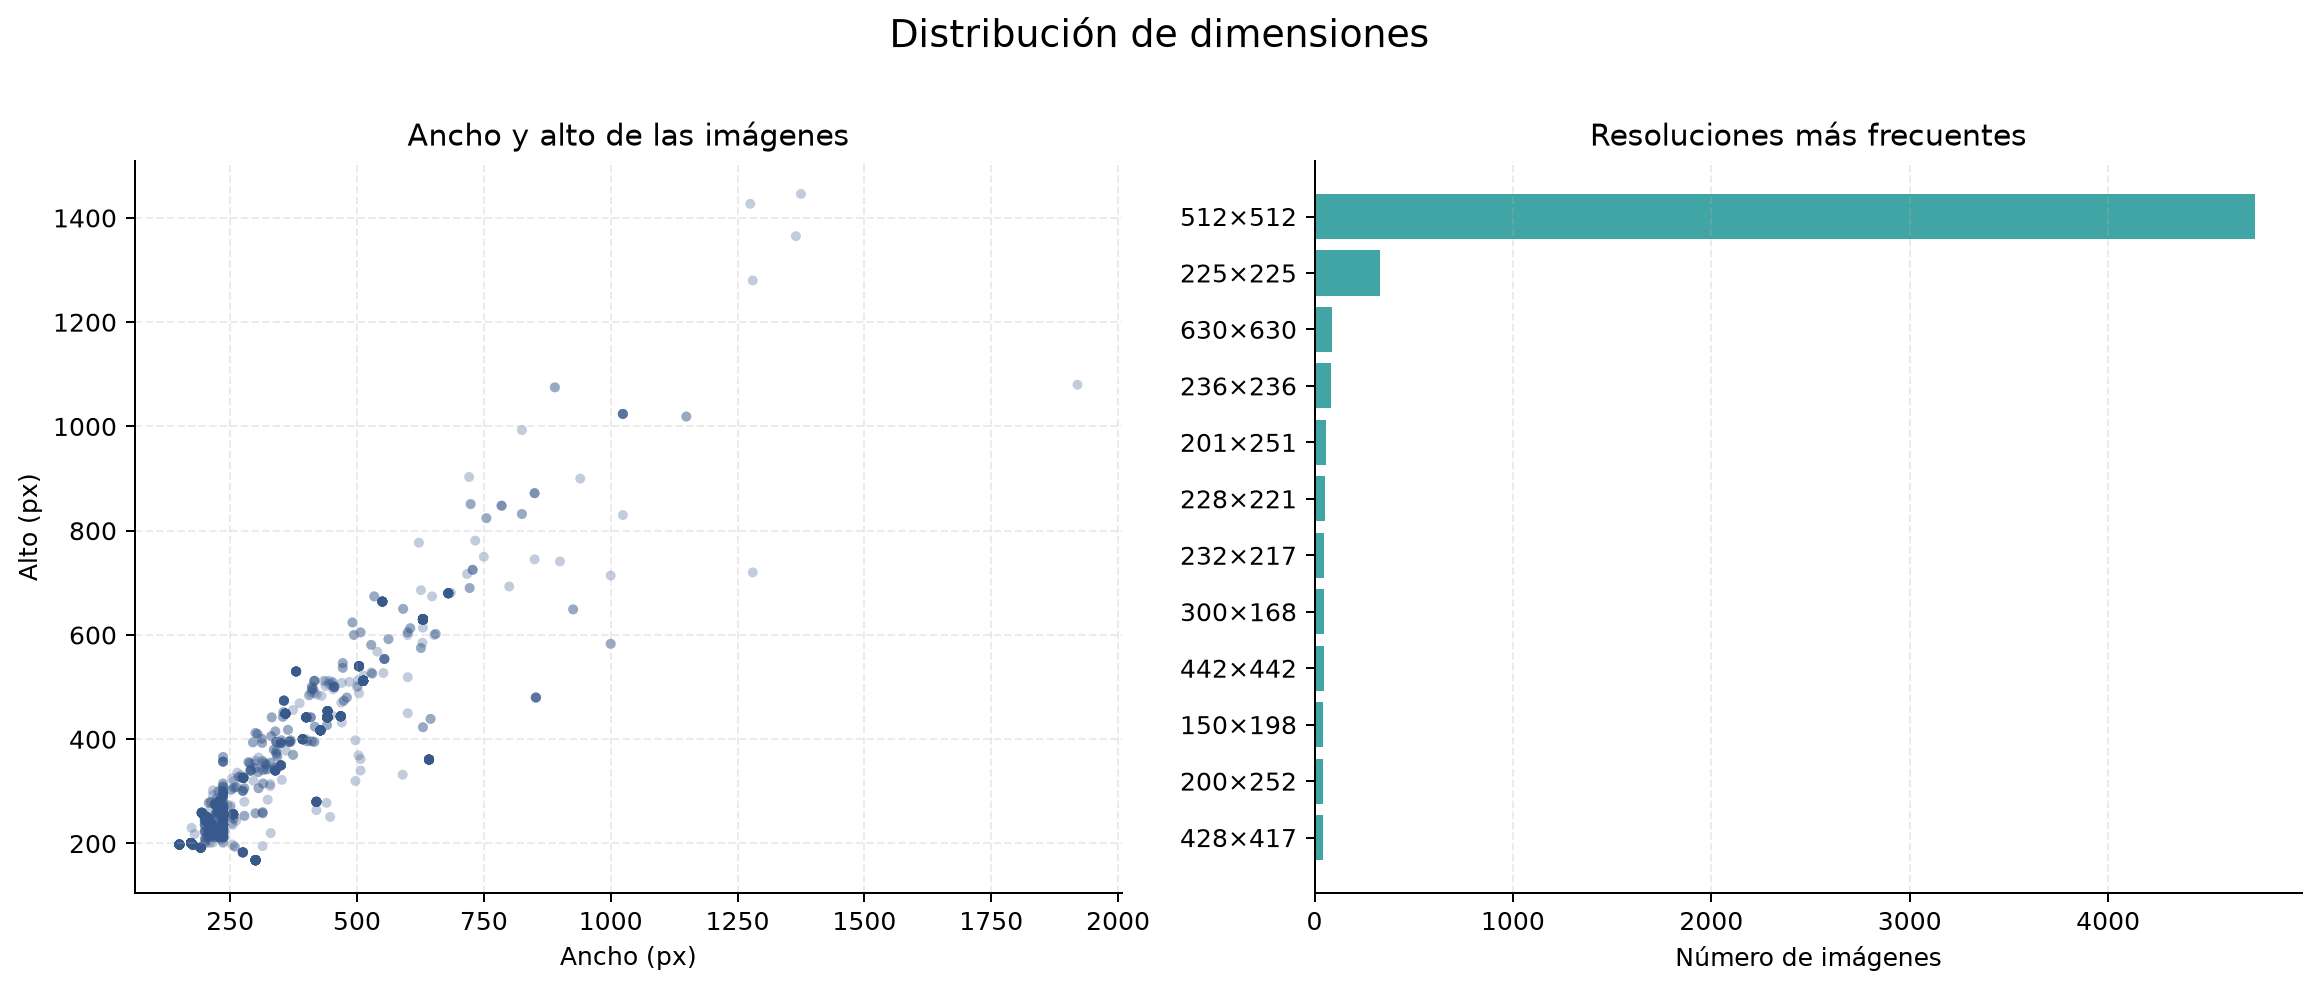

In [4]:
display(results['properties'])
display(DisplayImage(filename=str(output_dir / 'figures' / 'image_dimensions.png')))

## Distribución y ejemplos por clase

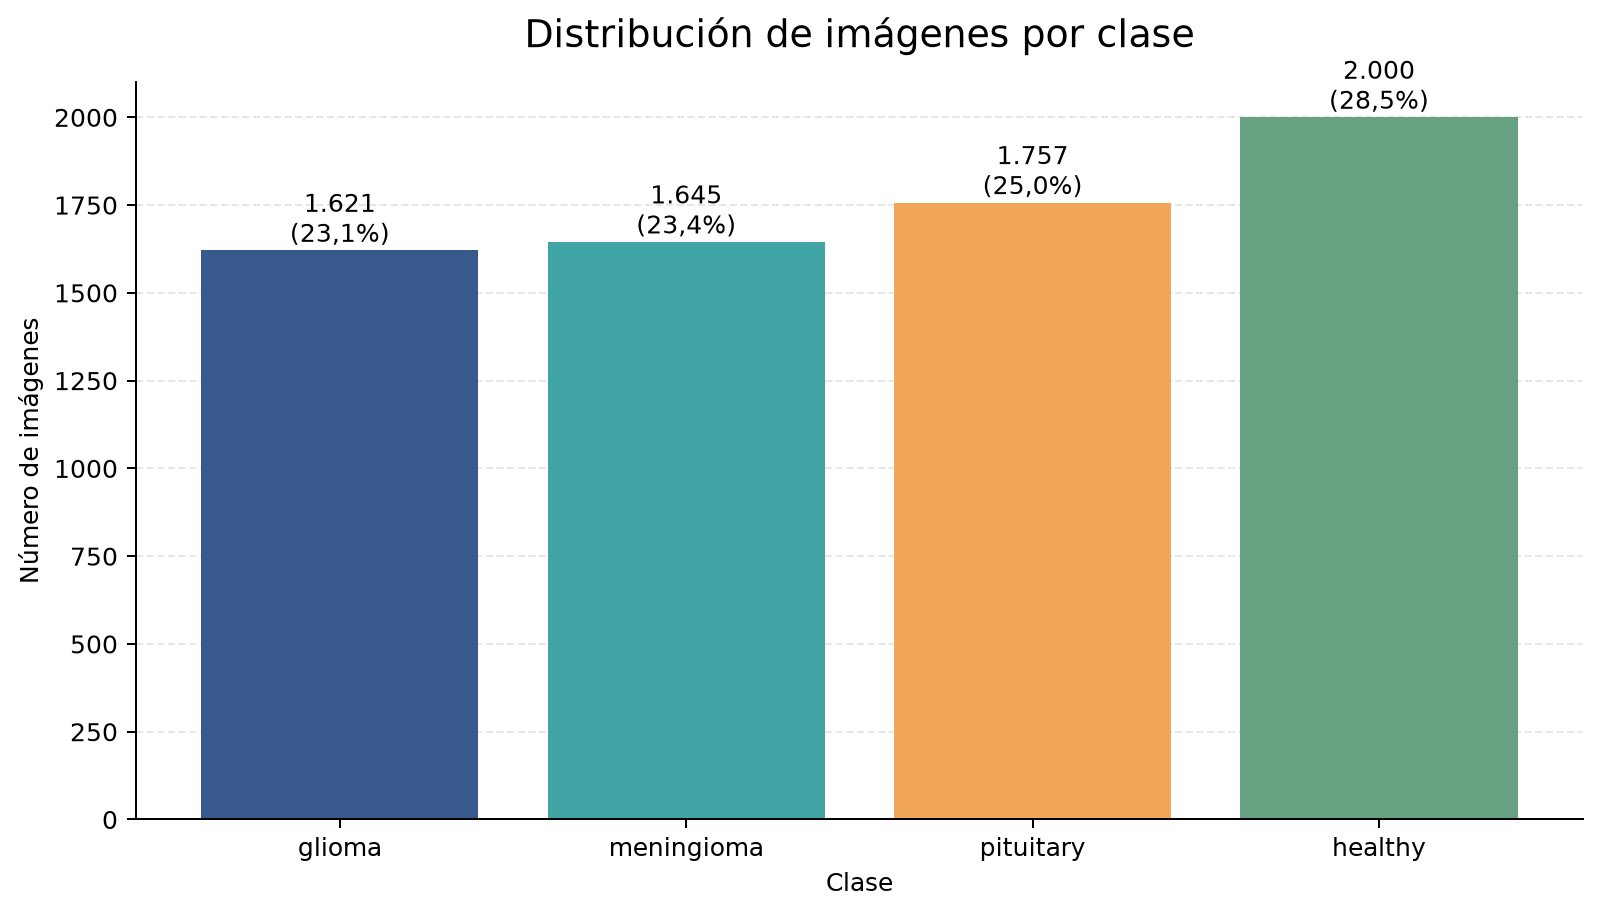

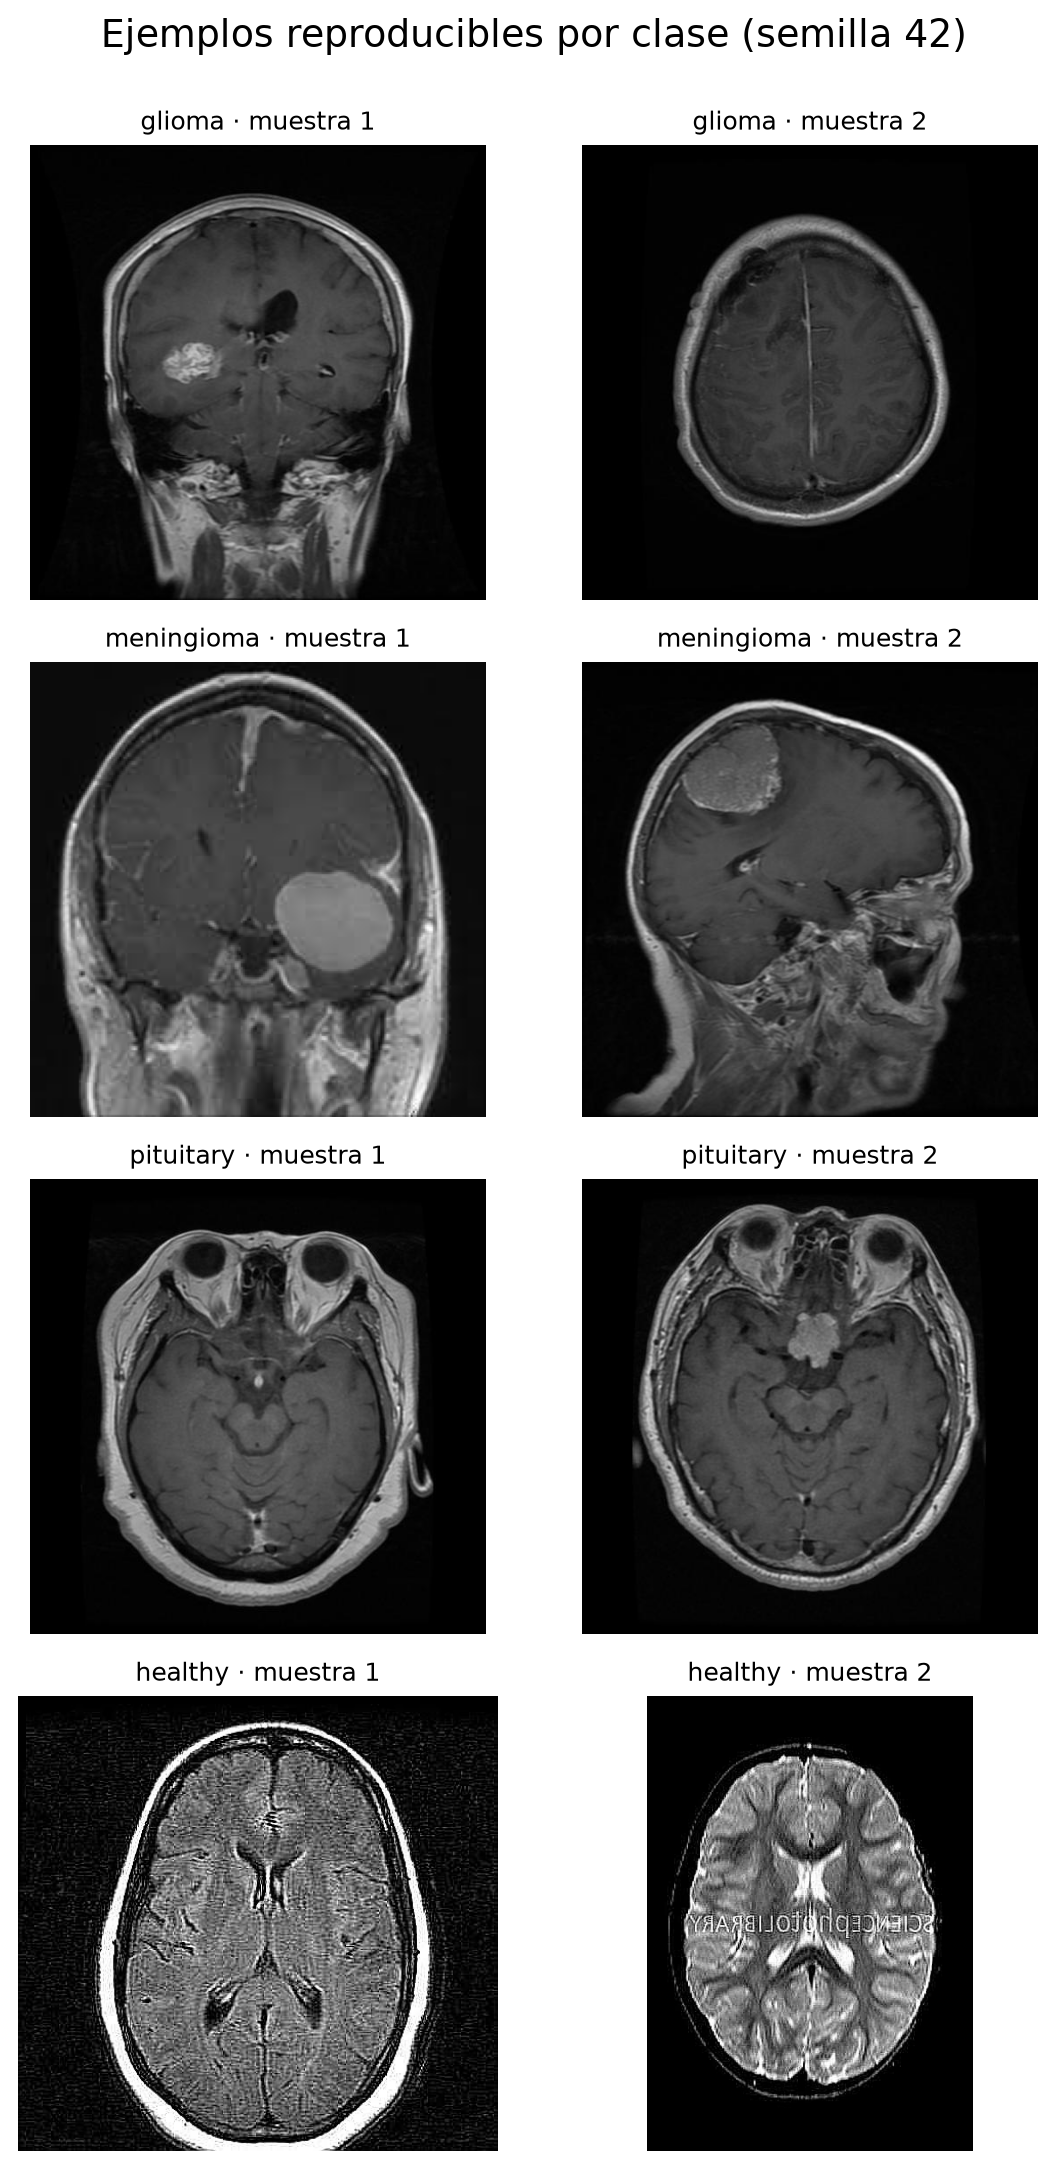

In [5]:
display(DisplayImage(filename=str(output_dir / 'figures' / 'class_distribution.png')))
display(DisplayImage(filename=str(output_dir / 'figures' / 'sample_images_by_class.png')))

## Conclusiones y limitaciones

In [6]:
display(Markdown((output_dir / 'eda_summary.md').read_text(encoding='utf-8')))

# Exploración del dataset Brain Tumor MRI Scans

## Alcance y método

Este análisis describe los archivos realmente encontrados en el dataset descargado mediante DVC. La ejecución inspeccionó cada archivo, verificó su lectura con Pillow, calculó SHA-256, resumió propiedades físicas y generó las visualizaciones con semilla fija `42`. No se entrenaron modelos ni se realizaron interpretaciones médicas.

## Inventario

Se encontraron **7.023 archivos de imagen**, de los cuales **7.023 son legibles**. Las clases reales son `glioma, meningioma, pituitary, healthy`.

- Clases esperadas ausentes: ninguna.
- Clases no esperadas: ninguna.
- Extensiones encontradas: .jpg (7023).

| clase      |   imagenes |   porcentaje |
|:-----------|-----------:|-------------:|
| glioma     |       1621 |        23.08 |
| meningioma |       1645 |        23.42 |
| pituitary  |       1757 |        25.02 |
| healthy    |       2000 |        28.48 |

### Particiones

| particion     |   imagenes |
|:--------------|-----------:|
| sin_particion |       7023 |

El valor `sin_particion` indica que los archivos están organizados directamente por clase y no incluyen un split original de entrenamiento, validación o prueba.

![Distribución de imágenes por clase](figures/class_distribution.png)

## Propiedades de las imágenes

| métrica                |   mínimo |    p05 |    p25 |   mediana |    p75 |    p95 |   máximo |
|:-----------------------|---------:|-------:|-------:|----------:|-------:|-------:|---------:|
| ancho_px               |   150.00 | 206.00 | 393.00 |    512.00 | 512.00 | 512.00 |  1920.00 |
| alto_px                |   168.00 | 221.00 | 403.50 |    512.00 | 512.00 | 512.00 |  1446.00 |
| relacion_aspecto       |     0.64 |   0.82 |   1.00 |      1.00 |   1.00 |   1.03 |     1.79 |
| tamano_kib             |     7.27 |  13.16 |  25.71 |     36.76 |  45.58 |  55.52 |   332.83 |
| intensidad_gris_global |     0.00 |   0.00 |   3.00 |     30.00 |  74.00 | 137.00 |   255.00 |

- Modos de color: RGB (7023).
- Número de canales: 3 (7023).
- La intensidad global se calculó después de convertir cada imagen a escala de grises, acumulando un histograma exacto de 256 niveles.
- Las dimensiones atípicas se marcaron mediante la regla de 1,5 IQR sobre `log2(ancho × alto)`.

![Distribución de dimensiones](figures/image_dimensions.png)

## Calidad de los datos

| métrica                             |   valor | detalle                                                           |
|:------------------------------------|--------:|:------------------------------------------------------------------|
| archivos_totales                    |    7023 | Todos los archivos encontrados                                    |
| archivos_de_imagen                  |    7023 | Archivos con extensión esperada o reconocidos por Pillow          |
| imagenes_legibles                   |    7023 | Imágenes verificadas y decodificadas por Pillow                   |
| archivos_vacios                     |       0 | Tamaño igual a 0 bytes                                            |
| imagenes_no_legibles                |       0 | Archivos candidatos que Pillow no pudo verificar o decodificar    |
| extensiones_no_esperadas            |       0 | Extensiones distintas de .jpg, .jpeg y .png                       |
| clases_esperadas_vacias             |       0 | Ninguna                                                           |
| clases_no_esperadas                 |       0 | Ninguna                                                           |
| dimensiones_atipicas                |    1574 | Área en log2 fuera de 1,5 IQR; si IQR=0, área distinta de la moda |
| grupos_duplicados_exactos           |     300 | Grupos con el mismo SHA-256                                       |
| archivos_en_grupos_duplicados       |     726 | Incluye el original y sus copias dentro de cada grupo             |
| copias_redundantes_exactas          |     426 | Archivos que sobran al conservar una copia por cada SHA-256       |
| grupos_duplicados_entre_clases      |       0 | Mismo SHA-256 asociado con más de una clase                       |
| grupos_duplicados_entre_particiones |       0 | No evaluable: el dataset no contiene particiones                  |

Se encontraron 300 grupos; el detalle está en `tables/exact_duplicates.csv`.

Como el dataset no trae particiones, no es posible comprobar todavía duplicados entre entrenamiento y prueba. Antes de entrenar, el equipo debe agrupar duplicados y posibles imágenes relacionadas antes de dividir los datos.

## Ejemplos por clase

La selección es determinista para la semilla `42`. Las imágenes se muestran únicamente para describir el dataset; no constituyen diagnósticos ni interpretaciones clínicas.

![Ejemplos reproducibles por clase](figures/sample_images_by_class.png)

## Conclusiones

1. El dataset contiene 7.023 archivos de imagen en 4 clases; la clase más numerosa es healthy (2.000) y la menor es glioma (1.621).
2. Se encontraron 387 resoluciones distintas; la más frecuente es 512×512 píxeles (67,5% de las imágenes). La regla estadística marcó 1.574 dimensiones atípicas; esto describe heterogeneidad de tamaños y no archivos corruptos.
3. La validación de lectura encontró 0 archivos de imagen no legibles y 0 archivos vacíos.
4. El análisis SHA-256 identificó 300 grupos de duplicados exactos; equivalen a 426 copias redundantes y 0 grupos aparecen asociados con más de una clase.
5. El dataset no incluye particiones de entrenamiento, validación o prueba; el riesgo de fuga entre particiones deberá controlarse cuando el equipo construya el split.

## Limitaciones

- El dataset público no aporta identificadores de paciente ni metadatos clínicos. SHA-256 detecta copias exactas, pero no imágenes casi duplicadas, cortes del mismo estudio ni pacientes repetidos.
- La ausencia de particiones impide evaluar fuga entre entrenamiento, validación y prueba en esta fase.
- La revisión comprueba integridad técnica y estructura de archivos; no valida la calidad clínica de las etiquetas.
- Los resultados corresponden a los archivos descargados mediante la versión DVC actual del repositorio.

Este conjunto público se emplea exclusivamente para un prototipo académico y no constituye una validación clínica ni un sistema autorizado para diagnóstico.

## Archivos reproducibles

- Inventario: [`tables/dataset_inventory.csv`](tables/dataset_inventory.csv)
- Calidad: [`tables/data_quality_summary.csv`](tables/data_quality_summary.csv)
- Duplicados exactos: [`tables/exact_duplicates.csv`](tables/exact_duplicates.csv)
- Metadatos por archivo: [`tables/image_metadata.csv`](tables/image_metadata.csv)
- Resumen de propiedades: [`tables/image_properties_summary.csv`](tables/image_properties_summary.csv)
